## Here I will test how robust a trained network is with respect to varying the parameters of the filters upon transfer.

In [1]:
import numpy as np
import torch
import torch.nn as nn
device='cpu'
torch.set_default_device(device)
class PhyKAN(nn.Module):
    def __init__(self, KANshape, filters_per_unit, thresholding=False, lr_decay=0.99, sigmoid_s=0.5):
        super().__init__()
        # Find number of layers
        self.Nlayers = len(KANshape)-1
        self.KANshape = KANshape
        # Create parameters for each layer
        self.filter_params = []
        self.thresholds = []
        self.edge_mask = []
        for i in range(self.Nlayers):
            low_params = torch.linspace(-1, 1, filters_per_unit).unsqueeze(0).unsqueeze(0).unsqueeze(-1)
            layer_params = torch.tile(low_params, (KANshape[i], KANshape[i+1], 1, 2))
            noise = (torch.rand(layer_params.shape)-0.5)*0.01
            layer_params = layer_params + noise
            gains = torch.rand((KANshape[i], KANshape[i+1], filters_per_unit, 1))/filters_per_unit
            params = torch.cat((gains, layer_params), dim=3)
            params.requires_grad=True
            self.filter_params.append(params)
            layer_mask = torch.ones((KANshape[i], KANshape[i+1]))
            self.edge_mask.append(layer_mask)
            if thresholding==True:
                thresholds = 0.25*torch.randn(KANshape[i])
                thresholds.requires_grad=True
            else:
                thresholds = torch.zeros(KANshape[i], requires_grad=True)
            self.thresholds.append(thresholds)
        # Initialise optimisers
        self.filter_optim = torch.optim.Adam(params=self.filter_params, lr=1e-3)
        self.threshold_optim = torch.optim.Adam(params=self.thresholds, lr=1e-5)
        self.sched1 = torch.optim.lr_scheduler.ExponentialLR(self.filter_optim, 0.99)
        self.lossfn = nn.MSELoss()
        self.thresholding=thresholding
        self.sigmoid_s = sigmoid_s
        
    def sig(self, x):
        return 1/(1+torch.exp(-x/self.sigmoid_s))
        
        
    # Redefined for torch & assuming trainable parameters
    def band_pass(self, Xin, params, mask):
        # Bound parameters
        params= self.sig(params)
        # Encode inputs to frequency space
        freq = 10**(3.69+2*Xin).unsqueeze(-1).unsqueeze(-1)
        # Allow bounded gains to be both positive and negative
        gain = 10*(params[:,:,:, 0].unsqueeze(0)-0.5)
        # Set cutoff frequencies from parameters
        fc_low = 10**(3.5+3*params[:,:,:, 1].unsqueeze(0))
        fc_high = 10**(3.5+3*params[:,:,:, 2].unsqueeze(0))
        # Convert cutoff frequency to product of resistance and capacitance
        RC_low = (2*torch.pi*fc_low)**-1
        RC_high = (2*torch.pi*fc_high)**-1
        # Calculate steady state response with respect to drive frequency
        Hout = gain*torch.abs((2j*torch.pi*freq*RC_low/(1+2j*torch.pi*freq*RC_low))*(1/(1+2j*torch.pi*freq*RC_high)))
        # Apply mask
        Hout = Hout * mask.unsqueeze(0).unsqueeze(-1)
        # Sum across units within each edge, and across multiple inputs to each node
        return Hout.sum(dim=1).sum(dim=-1)

    def band_pass_edges(self, Xin, params):
        # Bound parameters
        params= self.sig(params)
        # Encode inputs to frequency space
        freq = 10**(3.69+2*Xin).unsqueeze(-1).unsqueeze(-1)
        # Allow bounded gains to be both positive and negative
        gain = 10*(params[:, 0].unsqueeze(0)-0.5)
        # Set cutoff frequencies from parameters
        fc_low = 10**(3.5+3*params[:, 1].unsqueeze(0))
        fc_high = 10**(3.5+3*params[:, 2].unsqueeze(0))
        # Convert cutoff frequency to product of resistance and capacitance
        RC_low = (2*torch.pi*fc_low)**-1
        RC_high = (2*torch.pi*fc_high)**-1
        # Calculate steady state response with respect to drive frequency
        Hout = gain*torch.abs((2j*torch.pi*freq*RC_low/(1+2j*torch.pi*freq*RC_low))*(1/(1+2j*torch.pi*freq*RC_high)))
        # Sum across units within each edge
        return Hout.sum(dim=-1)
    
    # Redefined for torch & assuming trainable parameters
    def band_pass_single(self, Xin, params, threshold):
        # Threshold input
        Xin = (Xin-threshold).relu()
        # Bound parameters
        params=self.sig(params)
        # Normalise input of 0-1 to frequencies of 100 Hz-100 kHz
        freq = 10**(3.69+2*Xin).unsqueeze(-1).unsqueeze(-1)
        # For 'sensible' initialisation, we'd like parameters that make sense for gain, f_low, and f_high:
        # Set gain between +/- 5X
        gain = 10*(params[:, 0].unsqueeze(0)-0.5)
        # Set cutoff frequencies between 10 Hz and 1 MHz
        fc_low = 10**(3.5+3*params[:, 1].unsqueeze(0))
        fc_high = 10**(3.5+3*params[:, 2].unsqueeze(0))
        RC_low = (2*torch.pi*fc_low)**-1
        RC_high = (2*torch.pi*fc_high)**-1
        Hout = gain*torch.abs((2j*torch.pi*freq*RC_low/(1+2j*torch.pi*freq*RC_low))*(1/(1+2j*torch.pi*freq*RC_high)))
        return Hout.sum(dim=1).sum(dim=-1)
    
    def forward(self, Xin):
        batch_size = len(Xin)
        # Initialise inputs to and outputs from each layer
        inputs = []
        outputs = []
        for i in range(self.Nlayers):
            inputs.append(torch.zeros((batch_size, self.KANshape[i])))
            outputs.append(torch.zeros((batch_size, self.KANshape[i+1])))
        if self.thresholding==True:
            inputs[0][:, :] = self.sig((Xin-self.thresholds[0]))
        else:
            inputs[0][:,:] = self.sig((Xin))
        # Pass through model
        for layer in range(self.Nlayers):
            outputs[layer][:, :] = self.band_pass(inputs[layer], self.filter_params[layer], self.edge_mask[layer])
            if layer < self.Nlayers-1:
                if self.thresholding==True:
                    inputs[layer+1][:, :] = self.sig(outputs[layer][:, :]+self.thresholds[layer+1])
                else:
                    inputs[layer+1][:, :] = self.sig(outputs[layer][:, :])
        return outputs[-1]
    
    def train(self, Xin, Yin, penalty=True, lamda=1e-3):
        # Reset optimisers
        self.filter_optim.zero_grad()
        self.threshold_optim.zero_grad()
        # Pass through Model
        pred = self.forward(Xin)
        # Calculate loss
        loss_np = self.lossfn(pred, Yin)
        # Add penalty terms
        if penalty==True:
            penalty_loss = lamda * self.penalty()
            loss = loss_np + penalty_loss
        else:
            loss = loss_np
        # Backward pass
        loss.backward()
        # Update parameters
        self.filter_optim.step()
        self.threshold_optim.step()
        
        return loss.item(), loss_np.item()

    def penalty(self, n=1000):
        # Create input range to sample edge behaviour
        xin = torch.rand((n, self.KANshape[0]))
        # Get activations
        activations = self.forward_return_acts(xin)
        # Set up variable
        penalty = 0
        # Loop over layers
        for layer in range(self.Nlayers-1):
            # Calculate l1 penalties 
            l1_in = (1/n) * activations[layer].abs().sum(dim=0)/self.KANshape[layer]
            l1_out = (1/n) * activations[layer+1].abs().sum(dim=0)/self.KANshape[layer+1]
            l1_layer = l1_in.sum() + l1_out.sum()
            # Calculate entropy penalties (ReLU/ small addition is to prevent NaNs pruned edges)
            entropy_in = -1 * (l1_in/l1_layer) * torch.log(1e-9+ (l1_in/l1_layer).relu())
            entropy_out = -1 * (l1_out/l1_layer) * torch.log(1e-9 + (l1_out/l1_layer).relu())
            entropy_layer = (1/n)*(entropy_in.sum() + entropy_out.sum())
            # Combine terms
            penalty = penalty + l1_layer + entropy_layer
        return penalty
        
    def prune(self, threshold = 0.01):
        xs = torch.rand(10000, self.KANshape[0])
        outputs = self.forward_return_acts(xs)
        for layer in range(self.Nlayers-1):
            layerouts = torch.abs(outputs[layer]).mean(axis=0)
            for node, activation in enumerate(layerouts):
                if activation < threshold:
                    self.reshape(layer, node)

    def prune_edges(self, threshold = 0.05):
        xs = torch.linspace(0, 1, 1000)
        for layer in range(self.Nlayers-1):
            for pre in range(self.KANshape[layer]):
                for post in range(self.KANshape[layer+1]):
                    if self.edge_mask[layer][pre, post] == 0:
                        continue
                    edges = self.band_pass_edges(xs, self.filter_params[layer][pre, post])
                    if torch.abs(edges).mean() < threshold:
                        self.edge_mask[layer][pre, post] = 0
                        print('Pruning edge, layer '+str(layer)+' '+str(pre)+' '+str(post))
            
    def reshape(self, layer, node):
        newshape = []
        for l in range(self.Nlayers+1):
            if l != layer+1:
                newshape.append(self.KANshape[l])
            else:
                newshape.append(self.KANshape[l]-1)
        new_params = []
        flag = 0
        for l in range(self.Nlayers):
            if flag == 0:
                if l != layer:
                    new_params.append(self.filter_params[l])
                else:
                    layer_params=[]
                    for i in range(self.KANshape[l+1]):
                        if i != node:
                            layer_params.append(self.filter_params[l][:, i, :, :])
                    layer_params = torch.stack(layer_params, dim=1)
                    new_params.append(layer_params)
                    flag = 1
            else:
                layer_params=[]
                for i in range(self.KANshape[l]):
                    if i != node:
                        layer_params.append(self.filter_params[l][i, :, :, :])
                layer_params = torch.stack(layer_params, dim=0)
                new_params.append(layer_params)
                flag = 0
        self.KANshape = newshape
        self.filter_params = new_params
        print('Pruned: Layer '+str(layer)+', Node '+str(node))
        print('New Shape: '+str(self.KANshape))
                

    def forward_return_acts(self, Xin):
        batch_size = len(Xin)
        # Initialise inputs to and outputs from each layer
        inputs = []
        outputs = []
        for i in range(self.Nlayers):
            inputs.append(torch.zeros((batch_size, self.KANshape[i])))
            outputs.append(torch.zeros((batch_size, self.KANshape[i+1])))
        if self.thresholding==True:
            inputs[0][:, :] = self.sig((Xin-self.thresholds[0]))
        else:
            inputs[0][:,:] = self.sig((Xin))
        # Pass through model
        for layer in range(self.Nlayers):
            outputs[layer][:, :] = self.band_pass(inputs[layer], self.filter_params[layer], self.edge_mask[layer])
            if layer < self.Nlayers-1:
                if self.thresholding==True:
                    inputs[layer+1][:, :] = self.sig(outputs[layer][:, :]+self.thresholds[layer+1])
                else:
                    inputs[layer+1][:, :] = self.sig(outputs[layer][:, :])
        return outputs
    
    
class PhyKAN_robotics(nn.Module):
    def __init__(self, KANshape, filters_per_unit, forward_model, thresholding=False, lr_decay=0.99, sigmoid_s=0.5):
        super().__init__()
        # Find number of layers
        self.Nlayers = len(KANshape)-1
        self.KANshape = KANshape
        # Create parameters for each layer
        self.filter_params = []
        self.thresholds = []
        self.edge_mask = []
        for i in range(self.Nlayers):
            low_params = torch.linspace(-1, 1, filters_per_unit).unsqueeze(0).unsqueeze(0).unsqueeze(-1)
            layer_params = torch.tile(low_params, (KANshape[i], KANshape[i+1], 1, 2))
            noise = (torch.rand(layer_params.shape)-0.5)*0.01
            layer_params = layer_params + noise
            gains = torch.rand((KANshape[i], KANshape[i+1], filters_per_unit, 1))/filters_per_unit
            params = torch.cat((gains, layer_params), dim=3)
            params.requires_grad=True
            self.filter_params.append(params)
            layer_mask = torch.ones((KANshape[i], KANshape[i+1]))
            self.edge_mask.append(layer_mask)
            if thresholding==True:
                thresholds = 0.25*torch.randn(KANshape[i])
                thresholds.requires_grad=True
            else:
                thresholds = torch.zeros(KANshape[i], requires_grad=True)
            self.thresholds.append(thresholds)
        # Initialise optimisers
        self.filter_optim = torch.optim.Adam(params=self.filter_params, lr=1e-3)
        self.threshold_optim = torch.optim.Adam(params=self.thresholds, lr=1e-5)
        self.sched1 = torch.optim.lr_scheduler.ExponentialLR(self.filter_optim, 0.99)
        self.lossfn = nn.MSELoss()
        self.thresholding=thresholding
        self.sigmoid_s = sigmoid_s
        self.forward_model = forward_model
        
    def sig(self, x):
        return 1/(1+torch.exp(-x/self.sigmoid_s))
        
        
    # Redefined for torch & assuming trainable parameters
    def band_pass(self, Xin, params, mask):
        # Bound parameters
        params= self.sig(params)
        # Encode inputs to frequency space
        freq = 10**(3.69+2*Xin).unsqueeze(-1).unsqueeze(-1)
        # Allow bounded gains to be both positive and negative
        gain = 10*(params[:,:,:, 0].unsqueeze(0)-0.5)
        # Set cutoff frequencies from parameters
        fc_low = 10**(3.5+3*params[:,:,:, 1].unsqueeze(0))
        fc_high = 10**(3.5+3*params[:,:,:, 2].unsqueeze(0))
        # Convert cutoff frequency to product of resistance and capacitance
        RC_low = (2*torch.pi*fc_low)**-1
        RC_high = (2*torch.pi*fc_high)**-1
        # Calculate steady state response with respect to drive frequency
        Hout = gain*torch.abs((2j*torch.pi*freq*RC_low/(1+2j*torch.pi*freq*RC_low))*(1/(1+2j*torch.pi*freq*RC_high)))
        # Apply mask
        Hout = Hout * mask.unsqueeze(0).unsqueeze(-1)
        # Sum across units within each edge, and across multiple inputs to each node
        return Hout.sum(dim=1).sum(dim=-1)

    def band_pass_edges(self, Xin, params):
        # Bound parameters
        params= self.sig(params)
        # Encode inputs to frequency space
        freq = 10**(3.69+2*Xin).unsqueeze(-1).unsqueeze(-1)
        # Allow bounded gains to be both positive and negative
        gain = 10*(params[:, 0].unsqueeze(0)-0.5)
        # Set cutoff frequencies from parameters
        fc_low = 10**(3.5+3*params[:, 1].unsqueeze(0))
        fc_high = 10**(3.5+3*params[:, 2].unsqueeze(0))
        # Convert cutoff frequency to product of resistance and capacitance
        RC_low = (2*torch.pi*fc_low)**-1
        RC_high = (2*torch.pi*fc_high)**-1
        # Calculate steady state response with respect to drive frequency
        Hout = gain*torch.abs((2j*torch.pi*freq*RC_low/(1+2j*torch.pi*freq*RC_low))*(1/(1+2j*torch.pi*freq*RC_high)))
        # Sum across units within each edge
        return Hout.sum(dim=-1)
    
    # Redefined for torch & assuming trainable parameters
    def band_pass_single(self, Xin, params, threshold):
        # Threshold input
        Xin = (Xin-threshold).relu()
        # Bound parameters
        params=self.sig(params)
        # Normalise input of 0-1 to frequencies of 100 Hz-100 kHz
        freq = 10**(3.69+2*Xin).unsqueeze(-1).unsqueeze(-1)
        # For 'sensible' initialisation, we'd like parameters that make sense for gain, f_low, and f_high:
        # Set gain between +/- 5X
        gain = 10*(params[:, 0].unsqueeze(0)-0.5)
        # Set cutoff frequencies between 10 Hz and 1 MHz
        fc_low = 10**(3.5+3*params[:, 1].unsqueeze(0))
        fc_high = 10**(3.5+3*params[:, 2].unsqueeze(0))
        RC_low = (2*torch.pi*fc_low)**-1
        RC_high = (2*torch.pi*fc_high)**-1
        Hout = gain*torch.abs((2j*torch.pi*freq*RC_low/(1+2j*torch.pi*freq*RC_low))*(1/(1+2j*torch.pi*freq*RC_high)))
        return Hout.sum(dim=1).sum(dim=-1)
    
    def forward(self, Xin):
        batch_size = len(Xin)
        # Initialise inputs to and outputs from each layer
        inputs = []
        outputs = []
        for i in range(self.Nlayers):
            inputs.append(torch.zeros((batch_size, self.KANshape[i])))
            outputs.append(torch.zeros((batch_size, self.KANshape[i+1])))
        if self.thresholding==True:
            inputs[0][:, :] = self.sig((Xin-self.thresholds[0]))
        else:
            inputs[0][:,:] = self.sig((Xin))
        # Pass through model
        for layer in range(self.Nlayers):
            outputs[layer][:, :] = self.band_pass(inputs[layer], self.filter_params[layer], self.edge_mask[layer])
            if layer < self.Nlayers-1:
                if self.thresholding==True:
                    inputs[layer+1][:, :] = self.sig(outputs[layer][:, :]+self.thresholds[layer+1])
                else:
                    inputs[layer+1][:, :] = self.sig(outputs[layer][:, :])
        return outputs[-1]
    
    def train(self, Xin, Yin, penalty=True, lamda=1e-3):
        # Reset optimisers
        self.filter_optim.zero_grad()
        self.threshold_optim.zero_grad()
        # Pass through Model
        pred_vals = self.forward(Xin)
        true_loc = self.forward_model(pred_vals)
        # Calculate loss
        loss_np = self.lossfn(true_loc, Xin)
        # Add penalty terms
        if penalty==True:
            penalty_loss = lamda * self.penalty()
            loss = loss_np + penalty_loss
        else:
            loss = loss_np
        # Backward pass
        loss.backward()
        # Update parameters
        self.filter_optim.step()
        self.threshold_optim.step()
        
        return loss.item(), loss_np.item()

    def penalty(self, n=1000):
        # Create input range to sample edge behaviour
        xin = torch.rand((n, self.KANshape[0]))
        # Get activations
        activations = self.forward_return_acts(xin)
        # Set up variable
        penalty = 0
        # Loop over layers
        for layer in range(self.Nlayers-1):
            # Calculate l1 penalties 
            l1_in = (1/n) * activations[layer].abs().sum(dim=0)/self.KANshape[layer]
            l1_out = (1/n) * activations[layer+1].abs().sum(dim=0)/self.KANshape[layer+1]
            l1_layer = l1_in.sum() + l1_out.sum()
            # Calculate entropy penalties (ReLU/ small addition is to prevent NaNs pruned edges)
            entropy_in = -1 * (l1_in/l1_layer) * torch.log(1e-9+ (l1_in/l1_layer).relu())
            entropy_out = -1 * (l1_out/l1_layer) * torch.log(1e-9 + (l1_out/l1_layer).relu())
            entropy_layer = (1/n)*(entropy_in.sum() + entropy_out.sum())
            # Combine terms
            penalty = penalty + l1_layer + entropy_layer
        return penalty
        
    def prune(self, threshold = 0.01):
        xs = torch.rand(10000, self.KANshape[0])
        outputs = self.forward_return_acts(xs)
        for layer in range(self.Nlayers-1):
            layerouts = torch.abs(outputs[layer]).mean(axis=0)
            for node, activation in enumerate(layerouts):
                if activation < threshold:
                    self.reshape(layer, node)

    def prune_edges(self, threshold = 0.1):
        xs = torch.linspace(0, 1, 1000)
        for layer in range(self.Nlayers-1):
            for pre in range(self.KANshape[layer]):
                for post in range(self.KANshape[layer+1]):
                    if self.edge_mask[layer][pre, post] == 0:
                        continue
                    edges = self.band_pass_edges(xs, self.filter_params[layer][pre, post])
                    if torch.abs(edges).mean() < threshold:
                        self.edge_mask[layer][pre, post] = 0
                        print('Pruning edge, layer '+str(layer)+' '+str(pre)+' '+str(post))
        for layer in range(self.Nlayers-2):
            for post in range(self.KANshape[layer+1]):
                if self.edge_mask[layer][:, post].sum() == 0:
                        self.reshape(layer+1, post)
                        break
            
    def reshape(self, layer, node):
        newshape = []
        for l in range(self.Nlayers+1):
            if l != layer+1:
                newshape.append(self.KANshape[l])
            else:
                newshape.append(self.KANshape[l]-1)
        new_params = []
        new_mask = []
        flag = 0
        for l in range(self.Nlayers):
            if flag == 0:
                if l != layer:
                    new_params.append(self.filter_params[l])
                    new_mask.append(self.edge_mask[l])
                else:
                    layer_params=[]
                    mask = []
                    for i in range(self.KANshape[l+1]):
                        if i != node:
                            layer_params.append(self.filter_params[l][:, i, :, :])
                            mask.append(self.edge_mask[l][:, i])
                    layer_params = torch.stack(layer_params, dim=1)
                    mask = torch.stack(mask, dim=1)
                    new_params.append(layer_params)
                    new_mask.append(mask)
                    flag = 1
            else:
                layer_params=[]
                mask = []
                for i in range(self.KANshape[l]):
                    if i != node:
                        layer_params.append(self.filter_params[l][i, :, :, :])
                        mask.append(self.edge_mask[l][i])
                layer_params = torch.stack(layer_params, dim=0)
                mask = torch.stack(mask, dim=0)
                new_params.append(layer_params)
                new_mask.append(mask)
                flag = 0
        self.KANshape = newshape
        self.filter_params = new_params
        self.edge_mask = new_mask
        print('Pruned: Layer '+str(layer)+', Node '+str(node))
        print('New Shape: '+str(self.KANshape))
                

    def forward_return_acts(self, Xin):
        batch_size = len(Xin)
        # Initialise inputs to and outputs from each layer
        inputs = []
        outputs = []
        for i in range(self.Nlayers):
            inputs.append(torch.zeros((batch_size, self.KANshape[i])))
            outputs.append(torch.zeros((batch_size, self.KANshape[i+1])))
        if self.thresholding==True:
            inputs[0][:, :] = self.sig((Xin-self.thresholds[0]))
        else:
            inputs[0][:,:] = self.sig((Xin))
        # Pass through model
        for layer in range(self.Nlayers):
            outputs[layer][:, :] = self.band_pass(inputs[layer], self.filter_params[layer], self.edge_mask[layer])
            if layer < self.Nlayers-1:
                if self.thresholding==True:
                    inputs[layer+1][:, :] = self.sig(outputs[layer][:, :]+self.thresholds[layer+1])
                else:
                    inputs[layer+1][:, :] = self.sig(outputs[layer][:, :])
        return outputs    

## Here, I will explore the sensitivity of the parameters one by one:

In [2]:
def gen_samples(Xin, Yin, batch_size):
    indices = torch.randint(len(Xin), (batch_size,), device=device)
    Xsample = Xin[indices]
    Ysample = Yin[indices]
    return Xsample, Ysample

Xdata = np.load('Inverse Kinematics Inputs.npy')
Ydata = np.load('Inverse Kinematics Targets.npy')

idxs = np.arange(0, len(Xdata), 1, dtype='int')
np.random.shuffle(idxs)

shuffled_X = Xdata[idxs]
shuffled_Y = Ydata[idxs]

x_train, x_val = np.split(shuffled_X, [12000])
y_train, y_val = np.split(shuffled_Y, [12000])

x_train = torch.from_numpy(x_train).float().to(device)
x_val = torch.from_numpy(x_val).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
y_val = torch.from_numpy(y_val).float().to(device)

model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')
forward_model = torch.load('Forward Kinematics Model, N=9.pt', map_location=device)
with torch.no_grad():
    prediction = model.forward(x_val)
    true_location = forward_model.forward(prediction)
loss = model.lossfn(x_val, true_location)
print(loss.item())

0.02772604674100876


/tmp/ipykernel_16328/2087596757.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')
/tmp/ipykernel_16328/2

In [3]:
def add_gain_noise(model, noise_factor):
    new_params = []
    for layer in range(model.Nlayers):
        layer_params = model.sig(model.filter_params[layer])
        gain = 10*(layer_params[:, 0]-0.5)
        gain_noise = 2*(torch.rand(gain.shape)-0.5) * gain * noise_factor
        noised_gain = gain + gain_noise
        parameterised_gain = 0.5+(noised_gain/10)
        layer_params[:, 0] = parameterised_gain
        layer_params = layer_params.relu()
        layer_params = layer_params + 1e-9
        layer_params = layer_params.clamp(0, 1)
        inverted_sigmoid = model.sigmoid_s*torch.log(layer_params/(1-layer_params))
        new_params.append(inverted_sigmoid)
    model.filter_params = new_params
    
def add_RC_low_noise(model, noise_factor):
    new_params = []
    for layer in range(model.Nlayers):
        layer_params = model.sig(model.filter_params[layer])
        fc_low = 10**(3.5+3*layer_params[:, 1])
        RC_low = (2*torch.pi*fc_low)**-1
        RC_noise = 2*(torch.rand(RC_low.shape)-0.5) * RC_low * noise_factor
        noised_RC = RC_low + RC_noise
        parameterised_RC = (torch.log10(((2*torch.pi*noised_RC)**-1))-3.5)/3
        layer_params[:, 1] = parameterised_RC
        layer_params = layer_params.relu()
        layer_params = layer_params + 1e-9
        layer_params = layer_params.clamp(0, 1)
        inverted_sigmoid = model.sigmoid_s*torch.log(layer_params/(1-layer_params))
        new_params.append(inverted_sigmoid)
    model.filter_params = new_params
    
def add_RC_high_noise(model, noise_factor):
    new_params = []
    for layer in range(model.Nlayers):
        layer_params = model.sig(model.filter_params[layer])
        fc_high = 10**(3.5+3*layer_params[:, 2])
        RC_high = (2*torch.pi*fc_high)**-1
        RC_noise = 2*(torch.rand(RC_high.shape)-0.5) * RC_high * noise_factor
        noised_RC = RC_high + RC_noise
        parameterised_RC = (torch.log10(((2*torch.pi*noised_RC)**-1))-3.5)/3
        layer_params[:, 2] = parameterised_RC
        layer_params = layer_params.relu()
        layer_params = layer_params + 1e-9
        layer_params = layer_params.clamp(0, 1)
        inverted_sigmoid = model.sigmoid_s*torch.log(layer_params/(1-layer_params))
        new_params.append(inverted_sigmoid)
    model.filter_params = new_params

/tmp/ipykernel_16328/190184797.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  noised_model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')


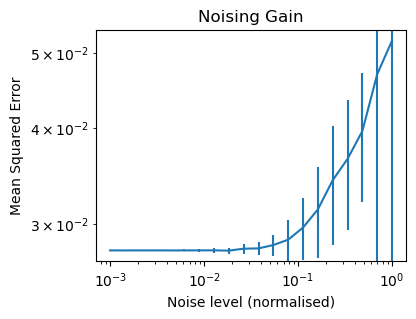

In [4]:
import matplotlib.pyplot as plt

noise_levels = np.logspace(-3, 0, 20)
noise_outputs = np.zeros((20, 100))
for i, noise_level in enumerate(noise_levels):
    for j in range(100):
        noised_model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')
        add_gain_noise(noised_model, noise_level)
        with torch.no_grad():
            prediction = noised_model.forward(x_val)
            true_location = forward_model.forward(prediction)
        loss = noised_model.lossfn(x_val, true_location)
        noise_outputs[i, j] = loss.item()
    

fig, ax = plt.subplots(figsize=(4, 3))
plt.title('Noising Gain')
ax.set_xscale('log')
ax.set_yscale('log')
ax.errorbar(noise_levels, noise_outputs.mean(axis=1), yerr=noise_outputs.std(axis=1))
ax.set_xlabel('Noise level (normalised)')
ax.set_ylabel('Mean Squared Error')
plt.show()

/tmp/ipykernel_16328/69607642.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  noised_model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')


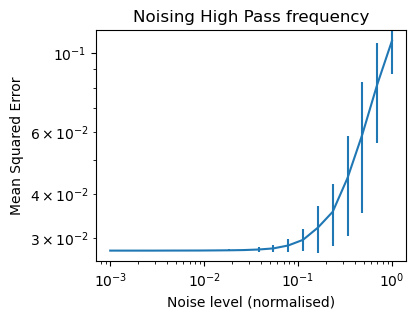

In [5]:
noise_levels = np.logspace(-3, 0, 20)
noise_outputs = np.zeros((20, 100))
for i, noise_level in enumerate(noise_levels):
    for j in range(100):
        noised_model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')
        add_RC_high_noise(noised_model, noise_level)
        with torch.no_grad():
            prediction = noised_model.forward(x_val)
            true_location = forward_model.forward(prediction)
        loss = noised_model.lossfn(x_val, true_location)
        noise_outputs[i, j] = loss.item()
    

fig, ax = plt.subplots(figsize=(4, 3))
plt.title('Noising High Pass frequency')
ax.set_xscale('log')
ax.set_yscale('log')
ax.errorbar(noise_levels, noise_outputs.mean(axis=1), yerr=noise_outputs.std(axis=1))
ax.set_xlabel('Noise level (normalised)')
ax.set_ylabel('Mean Squared Error')
plt.show()

/tmp/ipykernel_16328/2460672441.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  noised_model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')


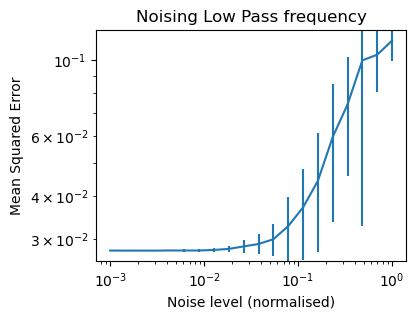

In [6]:
noise_levels = np.logspace(-3, 0, 20)
noise_outputs = np.zeros((20, 100))
for i, noise_level in enumerate(noise_levels):
    for j in range(100):
        noised_model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')
        add_RC_low_noise(noised_model, noise_level)
        with torch.no_grad():
            prediction = noised_model.forward(x_val)
            true_location = forward_model.forward(prediction)
        loss = noised_model.lossfn(x_val, true_location)
        noise_outputs[i, j] = loss.item()
    

fig, ax = plt.subplots(figsize=(4, 3))
plt.title('Noising Low Pass frequency')
ax.set_xscale('log')
ax.set_yscale('log')
ax.errorbar(noise_levels, noise_outputs.mean(axis=1), yerr=noise_outputs.std(axis=1))
ax.set_xlabel('Noise level (normalised)')
ax.set_ylabel('Mean Squared Error')
plt.show()

## Finally, here I will combine noise on each of the three parameters:

/tmp/ipykernel_16328/3022147248.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  noised_model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')


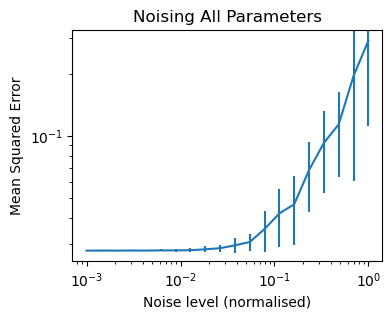

In [7]:
noise_levels = np.logspace(-3, 0, 20)
noise_outputs = np.zeros((20, 100))
for i, noise_level in enumerate(noise_levels):
    for j in range(100):
        noised_model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')
        add_gain_noise(noised_model, noise_level)
        add_RC_low_noise(noised_model, noise_level)
        add_RC_high_noise(noised_model, noise_level)
        with torch.no_grad():
            prediction = noised_model.forward(x_val)
            true_location = forward_model.forward(prediction)
        loss = noised_model.lossfn(x_val, true_location)
        noise_outputs[i, j] = loss.item()
    

fig, ax = plt.subplots(figsize=(4, 3))
plt.title('Noising All Parameters')
ax.set_xscale('log')
ax.set_yscale('log')
ax.errorbar(noise_levels, noise_outputs.mean(axis=1), yerr=noise_outputs.std(axis=1))
ax.set_xlabel('Noise level (normalised)')
ax.set_ylabel('Mean Squared Error')
plt.show()

## From these tests, it seems a parameter tolerance of 1% would be acceptable, but 0.1/0.01% are commonly available and would be preferred

/tmp/ipykernel_16328/424574587.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  noised_model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')


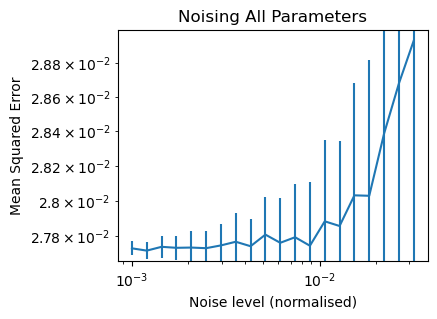

In [8]:
noise_levels = np.logspace(-3, -1.5, 20)
noise_outputs = np.zeros((20, 100))
for i, noise_level in enumerate(noise_levels):
    for j in range(100):
        noised_model = torch.load('Full Kinematics Model, N15, nfilt6, run0.pt')
        add_gain_noise(noised_model, noise_level)
        add_RC_low_noise(noised_model, noise_level)
        add_RC_high_noise(noised_model, noise_level)
        with torch.no_grad():
            prediction = noised_model.forward(x_val)
            true_location = forward_model.forward(prediction)
        loss = noised_model.lossfn(x_val, true_location)
        noise_outputs[i, j] = loss.item()
    

fig, ax = plt.subplots(figsize=(4, 3))
plt.title('Noising All Parameters')
ax.set_xscale('log')
ax.set_yscale('log')
ax.errorbar(noise_levels, noise_outputs.mean(axis=1), yerr=noise_outputs.std(axis=1))
ax.set_xlabel('Noise level (normalised)')
ax.set_ylabel('Mean Squared Error')
plt.show()